### Video processing

Upgraded FPS counter:

In [ ]:
import time
import cv2

class FPS_Counter:
    """ 
    Клас для підрахунку FPS (кадрів на секунду) з усередненням за певну кількість кадрів.

    Параметр calc_time_perion_N_frames визначає, за скільки кадрів будемо усереднювати FPS.
    """
    def __init__(self, calc_time_perion_N_frames: int) -> None:
        self.time_buffer = []
        self.calc_time_perion_N_frames = calc_time_perion_N_frames

    def calc_FPS(self) -> float:
        time_buffer_is_full = len(self.time_buffer) == self.calc_time_perion_N_frames
        t = time.time()
        self.time_buffer.append(t)

        if time_buffer_is_full:
            self.time_buffer.pop(0)
            fps = len(self.time_buffer) / (self.time_buffer[-1] - self.time_buffer[0])
            return np.round(fps, 2)
        else:
            return 0.0


def calc_and_show_fps(frame, fps_counter):
    """ 
    Відображає середнє значення FPS на кадрі frame в рамці.
    
    fps_counter - об'єкт класу FPS_Counter для підрахунку середнього FPS.
    """
    fps_real = fps_counter.calc_FPS()
    text = f"FPS: {fps_real:.1f}"
    
    (label_width, label_height), _ = cv2.getTextSize(
        text,
        fontFace=1,
        fontScale=1.3,
        thickness=1,
    )
    
    frame = cv2.rectangle(frame, (0, 0), (10 + label_width, 15 + label_height), (0, 0, 0), -1)
    frame = cv2.putText(
        img=frame,
        text=text,
        org=(5, 20),
        fontFace=1,
        fontScale=1.3,
        thickness=1,
        color=(255, 255, 255),
    )
    return frame

In [3]:
from ultralytics import YOLO
import numpy as np
import cv2
import json

def process_video_with_tracking(model, input_video, show_video=True, save_video=False):
    # Open the input video file
    input_video_path = f'input_videos/{input_video}.mp4' if input_video != 0 else 0
    cap = cv2.VideoCapture(input_video_path)

    if not cap.isOpened():
        raise Exception("Error: Could not open video file.")

    fps_counter = FPS_Counter(calc_time_perion_N_frames=30) # Average fps for 30 frames

    # Get input video frame rate and dimensions
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define the output video writer
    if save_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        input_video = 'life_camera' if input_video == 0 else input_video
        output_path = f'output_videos/{input_video}_result.mp4' 
        out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))


    colors = {
        'CocaCola': (0, 0, 255),  # Red
        'Pepsi': (255, 0, 0)     # Blue
    }

    # Polygons coordinates
    zone_A = [(5, 5), 
              (frame_width*0.25, 5), 
              (frame_width*0.45, frame_height - 5), 
              (5, frame_height - 5)
    ]
    zone_B = [(frame_width*0.75, 5), 
              (frame_width - 5, 5), 
              (frame_width - 5, frame_height - 5),
              (frame_width*0.55, frame_height - 5)    
    ]

    # Total counters for all video
    total_counts = {
        "zone_A": {"coca_cola": 0, "pepsi": 0},
        "zone_B": {"coca_cola": 0, "pepsi": 0}
    }

    # Sets to track unique object IDs in each zone
    tracked_objects_A = set()
    tracked_objects_B = set()


    # ========== Main cycle for video processing ==========
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Track objects in the frame
        results = model.track(source=frame, persist=True, conf=0.8, verbose=False, tracker="bytetrack.yaml")[0]

        # Counter for current frame
        counts = {
            "zone_A": {"coca_cola": 0, "pepsi": 0},
            "zone_B": {"coca_cola": 0, "pepsi": 0}
        }

        # ===== Find all objects on the frame =====
        for box in results.boxes:
            cls_id = int(box.cls[0])
            label = model.names[cls_id]
            conf = box.conf[0]
            track_id = int(box.id[0]) if box.id is not None else None
                
            if track_id is None:
                continue
                
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx, cy = int((x1+x2)/2), int((y1+y2)/2)  # object center
            color = colors.get(label[:-4], (255, 255, 255)) # white by default
            label_text = f"{label[:-4]}: {int(conf*100)}%"
            
            # Draw bounding box and center
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.circle(frame, (cx, cy), 2, (0,255,0), -1)

            # Draw object label
            (label_width, label_height), _ = cv2.getTextSize(
                label_text,
                fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=0.5,
                thickness=1,
            )
            cv2.rectangle(frame, (x1 - 1, y1 - label_height - 12), (x1 + label_width + 5, y1), color, -1)
            cv2.putText(frame, label_text, (x1 + 1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)


            # Unique object identifier for total counting
            object_id = f"{track_id}_{label}"

            # === Check if object center is in zone A ===
            if cv2.pointPolygonTest(np.array(zone_A, np.int32), (cx, cy), True) >= 0:
                if label == "CocaCola_0.5":
                    counts["zone_A"]["coca_cola"] += 1
                    if object_id not in tracked_objects_A: # add to total count only once
                        total_counts["zone_A"]["coca_cola"] += 1
                        tracked_objects_A.add(object_id)
                elif label == "Pepsi_0.5":
                    counts["zone_A"]["pepsi"] += 1
                    if object_id not in tracked_objects_A: # add to total count only once
                        total_counts["zone_A"]["pepsi"] += 1
                        tracked_objects_A.add(object_id)

            # === Check if object center is in zone B ===
            if cv2.pointPolygonTest(np.array(zone_B, np.int32), (cx, cy), True) >= 0:
                if label == "CocaCola_0.5":
                    counts["zone_B"]["coca_cola"] += 1
                    if object_id not in tracked_objects_B: # add to total count only once
                        total_counts["zone_B"]["coca_cola"] += 1
                        tracked_objects_B.add(object_id)
                elif label == "Pepsi_0.5":
                    counts["zone_B"]["pepsi"] += 1
                    if object_id not in tracked_objects_B: # add to total count only once
                        total_counts["zone_B"]["pepsi"] += 1
                        tracked_objects_B.add(object_id)


        # === Draw polygons, counts and labels on the frame ===
        cv2.putText(frame, 
                    f'Cola: {counts["zone_A"]["coca_cola"]}, Pepsi: {counts["zone_A"]["pepsi"]}', 
                    (10, frame_height - 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (0,255,0), 2
        )
        cv2.putText(frame, 
                    f'Cola: {counts["zone_B"]["coca_cola"]}, Pepsi: {counts["zone_B"]["pepsi"]}',
                    (frame_width - 280, frame_height - 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (0,255,0), 2
        )
        cv2.polylines(frame, [np.array(zone_A, np.int32)], True, (0,255,0), 2)
        cv2.putText(frame, 'A', (int(frame_width*0.2), 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
        cv2.polylines(frame, [np.array(zone_B, np.int32)], True, (0,255,0), 2)
        cv2.putText(frame, 'B', (int(frame_width*0.78), 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)


        # FPS calculation and display
        frame = calc_and_show_fps(frame, fps_counter)

        # Save video as file
        if save_video:
            out.write(frame)

        # Show video on screen
        if show_video:
            cv2.imshow('Object Detection', frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break


    # Print total counts as JSON
    print(json.dumps(total_counts, indent=2))
    
    # Release the input video capture and output video writer
    cap.release()
    if save_video:
        out.release()

    # Close all OpenCV windows
    cv2.destroyAllWindows()


# Example usage:
model = YOLO('ColaPepsiNet.pt')
model.fuse()
results = process_video_with_tracking(model, 
                                      input_video = 'video_2',
                                      show_video=True,
                                      save_video=False
                                      )

Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
{
  "zone_A": {
    "coca_cola": 2,
    "pepsi": 3
  },
  "zone_B": {
    "coca_cola": 3,
    "pepsi": 1
  }
}


### Image processing

Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
Pepsi: 96%
CocaCola: 96%
CocaCola: 95%
CocaCola: 95%
CocaCola: 95%
Pepsi: 92%
Pepsi: 90%


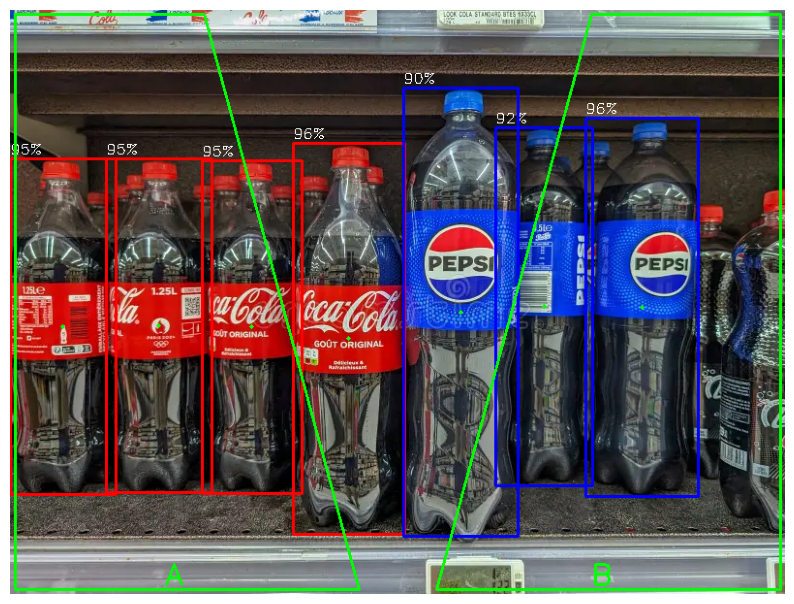

{
  "zone_A": {
    "coca_cola": 3,
    "pepsi": 0
  },
  "zone_B": {
    "coca_cola": 0,
    "pepsi": 2
  }
}


In [ ]:
import cv2
import json
from ultralytics import YOLO
import matplotlib.pyplot as plt

def process_photo(model, image_path):
    img = cv2.imread(image_path)
    results = model.track(source=img, persist=True, conf=0.6, verbose=False)[0]

    colors = {
        'CocaCola': (0, 0, 255),  # Red
        'Pepsi': (255, 0, 0)     # Blue
    }

    # Object counters for image
    counts = {
        "zone_A": {"coca_cola": 0, "pepsi": 0},
        "zone_B": {"coca_cola": 0, "pepsi": 0}
    }
    
    # === Polygons coordinates ===
    height, width, _ = img.shape 
    zone_A = [(5, 5), 
              (width*0.25, 5), 
              (width*0.45, height - 5), 
              (5, height - 5)
    ]
    zone_B = [(width*0.75, 5), 
              (width - 5, 5), 
              (width - 5, height - 5),
              (width*0.55, height - 5)    
    ]


    # ===== Find all objects on the image =====
    for box in results.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        conf = box.conf[0]
        track_id = int(box.id[0]) if box.id is not None else None
            
        if track_id is None:
            continue
            
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cx, cy = int((x1+x2)/2), int((y1+y2)/2)  # object center
        color = colors.get(label[:-4], (255, 255, 255)) # white by default

        label_text = f"{label[:-4]}: {int(conf*100)}%"
        print(label_text)
        
        # Draw bounding box and center
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.circle(img, (cx, cy), 2, (0,255,0), -1)
        cv2.putText(img=img, 
                    text=f"{int(conf*100)}%",
                    org = (x1, y1 - 5),
                    fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                    fontScale=0.5,
                    thickness=1, 
                    color=(255, 255, 255)
        )
        

        # === Check if center is in zone A ===
        if cv2.pointPolygonTest(np.array(zone_A, np.int32), (cx, cy), False) > 0:
            if label == "CocaCola_0.5":
                counts["zone_A"]["coca_cola"] += 1
            elif label == "Pepsi_0.5":
                counts["zone_A"]["pepsi"] += 1

        # === Check if center is in zone B ===
        elif cv2.pointPolygonTest(np.array(zone_B, np.int32), (cx, cy), False) > 0:
            if label == "CocaCola_0.5":
                counts["zone_B"]["coca_cola"] += 1
            elif label == "Pepsi_0.5":
                counts["zone_B"]["pepsi"] += 1


        # Draw polygons and labels on the frame
        cv2.polylines(img, [np.array(zone_A, np.int32)], True, (0,255,0), 2)
        cv2.putText(img, 'A', (int(width*0.2), height - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
        cv2.polylines(img, [np.array(zone_B, np.int32)], True, (0,255,0), 2)
        cv2.putText(img, 'B', (int(width*0.75), height - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)


    # Show image with matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

    # Print counts as JSON
    print(json.dumps(counts, indent=2))


# # Example usage:
model = YOLO('ColaPepsiNet.pt')
model.fuse()
process_photo(model, image_path = "image1.webp")